# Claims Dataset — Correlation Analysis & Visualization

This notebook explores the `Claims_dataset.csv` file: it loads and cleans the data, computes correlation metrics between numeric fields, and visualizes the relationships and distributions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 60)

df = pd.read_csv("Claims_dataset.csv")
print(df.shape)
df.head()

(1000, 53)


,months_as_customer,age,policy_number,policy_bind_date,policy_state,plan_type,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,insured_sex,insured_education_level,insured_occupation,insured_hobbies,insured_relationship,capital-gains,capital-loss,encounter_date,encounter_type,care_setting,condition_severity_level,referral_source,incident_state,incident_city,place_of_service_code,place_of_service_description,incident_hour_of_the_day,number_of_chronic_conditions,prior_authorization_required,bodily_injuries,witnesses,doctor_report_available,total_claim_amount,physician_claim_amt,facility_claim_amt,pharmacy_claim_amt,dme_equipment_type,dme_manufacturer,dme_model,dme_year_issued,fraud_reported,documentation_gap_flag,primary_icd10_code,primary_icd10_description,secondary_icd10_code,secondary_icd10_description,hcc_category,hcc_raf_weight,cms_hcc_model_version,chronic_condition_flag,provider_npi,provider_specialty,risk_adjustment_payment_year
0,328,48,521585,17-10-2014,OH,HMO,1000,1406.91,0,466132,MALE,MD,craft-repair,sleeping,husband,53300,0,25-01-2015,Chronic Disease Management Visit,Inpatient Hospital,Critical / Life-Threatening,Care Manager / Case Management,OH,Columbus,22,On Campus-Outpatient Hospital,5,2,YES,1,2,YES,71610,6510,13020,52080,CPAP Machine,Philips Respironics,PHI-992,2021.0,Y,N,E66.01,Morbid (severe) obesity due to excess calories,M19.90,"Osteoarthritis, unspecified site",HCC22 - Morbid Obesity,0.250,CMS-HCC V28,Y,1195266390,Internal Medicine,2016
1,228,42,342868,27-06-2006,IN,HMO,2000,1197.22,5000000,468176,MALE,MD,machine-op-inspct,reading,other-relative,0,0,21-01-2015,Telehealth Chronic Care Check-in,Home Health,Critical / Life-Threatening,NaN,IN,Riverwood,31,Skilled Nursing Facility,8,3,YES,0,0,NO,5070,780,780,3510,NaN,NaN,NaN,NaN,Y,N,F32.9,"Major depressive disorder, single episode, uns...",K21.9|I10,Gastro-esophageal reflux disease without esoph...,HCC59 - Major Depressive Disorder,0.309,CMS-HCC V28,Y,1876211728,Psychiatry,2016
2,134,29,687698,06-09-2000,OH,PPO,2000,1413.14,5000000,430632,FEMALE,PhD,sales,board-games,own-child,35100,0,22-02-2015,Diagnostic Screening / Lab Work,Telehealth,Stable / Controlled,Primary Care Physician,OH,Columbus,2,Telehealth,7,2,YES,2,3,NO,34650,7700,3850,23100,NaN,NaN,NaN,NaN,N,Y,I25.10,Atherosclerotic heart disease of native corona...,M19.90,"Osteoarthritis, unspecified site",HCC88 - Vascular Disease,0.299,CMS-HCC V28,Y,1855923908,Cardiology,2016
3,256,41,227811,25-05-1990,IL,HMO,2000,1415.74,6000000,608117,FEMALE,PhD,armed-forces,board-games,unmarried,48900,-62400,10-01-2015,Chronic Disease Management Visit,Telehealth,Stable / Controlled,NaN,IL,Arlington,23,Emergency Room - Hospital,5,1,YES,1,2,NO,63400,6340,6340,50720,NaN,NaN,NaN,NaN,Y,N,N18.3,"Chronic kidney disease, stage 3",NaN,NaN,HCC138 - Chronic Kidney Disease Stage 3-4,0.237,CMS-HCC V28,Y,1403500987,Nephrology,2016
4,228,44,367455,06-06-2014,IL,PFFS,1000,1583.91,6000000,610706,MALE,Associate,sales,board-games,unmarried,66000,-46000,17-02-2015,Specialist Referral Visit,Home Health,Critical / Life-Threatening,NaN,IL,Arlington,22,On Campus-Outpatient Hospital,20,2,YES,0,1,NO,6500,1300,650,4550,NaN,NaN,NaN,NaN,N,N,M06.9,"Rheumatoid arthritis, unspecified",M19.90,"Osteoarthritis, unspecified site",HCC40 - Rheumatoid Arthritis/Inflammatory,0.423,CMS-HCC V28,Y,1756982696,Rheumatology,2016


## 1. Data Overview

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 53 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   months_as_customer            1000 non-null   int64  
 1   age                           1000 non-null   int64  
 2   policy_number                 1000 non-null   int64  
 3   policy_bind_date              1000 non-null   str    
 4   policy_state                  1000 non-null   str    
 5   plan_type                     1000 non-null   str    
 6   policy_deductable             1000 non-null   int64  
 7   policy_annual_premium         1000 non-null   float64
 8   umbrella_limit                1000 non-null   int64  
 9   insured_zip                   1000 non-null   int64  
 10  insured_sex                   1000 non-null   str    
 11  insured_education_level       1000 non-null   str    
 12  insured_occupation            1000 non-null   str    
 13  insured_hobbies

In [3]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
months_as_customer,1000.0,NaN,NaN,NaN,203.954,115.113174,0.0,115.75,199.5,276.25,479.0
age,1000.0,NaN,NaN,NaN,38.948,9.140287,19.0,32.0,38.0,44.0,64.0
policy_number,1000.0,NaN,NaN,NaN,546238.648,257063.005276,100804.0,335980.25,533135.0,759099.75,999435.0
policy_bind_date,1000,951,01-01-2006,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
policy_state,1000,3,OH,352,NaN,NaN,NaN,NaN,NaN,NaN,NaN
plan_type,1000,3,HMO,351,NaN,NaN,NaN,NaN,NaN,NaN,NaN
policy_deductable,1000.0,NaN,NaN,NaN,1136.0,611.864673,500.0,500.0,1000.0,2000.0,2000.0
policy_annual_premium,1000.0,NaN,NaN,NaN,1256.40615,244.167395,433.33,1089.6075,1257.2,1415.695,2047.59
umbrella_limit,1000.0,NaN,NaN,NaN,1101000.0,2297406.598118,-1000000.0,0.0,0.0,0.0,10000000.0
insured_zip,1000.0,NaN,NaN,NaN,501214.488,71701.610941,430104.0,448404.5,466445.5,603251.0,620962.0


In [4]:
# Missing values
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing

secondary_icd10_description    416
secondary_icd10_code           416
dme_equipment_type             415
dme_year_issued                415
dme_manufacturer               415
dme_model                      415
referral_source                170
dtype: int64

## 2. Light Cleaning

- Parse date columns
- Convert `fraud_reported` (Y/N) and `documentation_gap_flag` (Y/N) into binary numeric flags so they can be included in the correlation analysis
- Convert `chronic_condition_flag` and `prior_authorization_required` similarly

In [5]:
df_clean = df.copy()

# Parse dates
for col in ["policy_bind_date", "encounter_date"]:
    df_clean[col] = pd.to_datetime(df_clean[col], format="%d-%m-%Y", errors="coerce")

# Binary-encode Y/N style columns
yn_cols = ["fraud_reported", "documentation_gap_flag", "chronic_condition_flag",
           "prior_authorization_required", "doctor_report_available"]
for col in yn_cols:
    if col in df_clean.columns:
        df_clean[col + "_bin"] = df_clean[col].map({"Y": 1, "N": 0, "YES": 1, "NO": 0})

df_clean.head()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,plan_type,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,insured_sex,insured_education_level,insured_occupation,insured_hobbies,insured_relationship,capital-gains,capital-loss,encounter_date,encounter_type,care_setting,condition_severity_level,referral_source,incident_state,incident_city,place_of_service_code,place_of_service_description,incident_hour_of_the_day,number_of_chronic_conditions,prior_authorization_required,bodily_injuries,witnesses,doctor_report_available,total_claim_amount,physician_claim_amt,facility_claim_amt,pharmacy_claim_amt,dme_equipment_type,dme_manufacturer,dme_model,dme_year_issued,fraud_reported,documentation_gap_flag,primary_icd10_code,primary_icd10_description,secondary_icd10_code,secondary_icd10_description,hcc_category,hcc_raf_weight,cms_hcc_model_version,chronic_condition_flag,provider_npi,provider_specialty,risk_adjustment_payment_year,fraud_reported_bin,documentation_gap_flag_bin,chronic_condition_flag_bin,prior_authorization_required_bin,doctor_report_available_bin
0,328,48,521585,2014-10-17,OH,HMO,1000,1406.91,0,466132,MALE,MD,craft-repair,sleeping,husband,53300,0,2015-01-25,Chronic Disease Management Visit,Inpatient Hospital,Critical / Life-Threatening,Care Manager / Case Management,OH,Columbus,22,On Campus-Outpatient Hospital,5,2,YES,1,2,YES,71610,6510,13020,52080,CPAP Machine,Philips Respironics,PHI-992,2021.0,Y,N,E66.01,Morbid (severe) obesity due to excess calories,M19.90,"Osteoarthritis, unspecified site",HCC22 - Morbid Obesity,0.250,CMS-HCC V28,Y,1195266390,Internal Medicine,2016,1,0,1,1,1
1,228,42,342868,2006-06-27,IN,HMO,2000,1197.22,5000000,468176,MALE,MD,machine-op-inspct,reading,other-relative,0,0,2015-01-21,Telehealth Chronic Care Check-in,Home Health,Critical / Life-Threatening,NaN,IN,Riverwood,31,Skilled Nursing Facility,8,3,YES,0,0,NO,5070,780,780,3510,NaN,NaN,NaN,NaN,Y,N,F32.9,"Major depressive disorder, single episode, uns...",K21.9|I10,Gastro-esophageal reflux disease without esoph...,HCC59 - Major Depressive Disorder,0.309,CMS-HCC V28,Y,1876211728,Psychiatry,2016,1,0,1,1,0
2,134,29,687698,2000-09-06,OH,PPO,2000,1413.14,5000000,430632,FEMALE,PhD,sales,board-games,own-child,35100,0,2015-02-22,Diagnostic Screening / Lab Work,Telehealth,Stable / Controlled,Primary Care Physician,OH,Columbus,2,Telehealth,7,2,YES,2,3,NO,34650,7700,3850,23100,NaN,NaN,NaN,NaN,N,Y,I25.10,Atherosclerotic heart disease of native corona...,M19.90,"Osteoarthritis, unspecified site",HCC88 - Vascular Disease,0.299,CMS-HCC V28,Y,1855923908,Cardiology,2016,0,1,1,1,0
3,256,41,227811,1990-05-25,IL,HMO,2000,1415.74,6000000,608117,FEMALE,PhD,armed-forces,board-games,unmarried,48900,-62400,2015-01-10,Chronic Disease Management Visit,Telehealth,Stable / Controlled,NaN,IL,Arlington,23,Emergency Room - Hospital,5,1,YES,1,2,NO,63400,6340,6340,50720,NaN,NaN,NaN,NaN,Y,N,N18.3,"Chronic kidney disease, stage 3",NaN,NaN,HCC138 - Chronic Kidney Disease Stage 3-4,0.237,CMS-HCC V28,Y,1403500987,Nephrology,2016,1,0,1,1,0
4,228,44,367455,2014-06-06,IL,PFFS,1000,1583.91,6000000,610706,MALE,Associate,sales,board-games,unmarried,66000,-46000,2015-02-17,Specialist Referral Visit,Home Health,Critical / Life-Threatening,NaN,IL,Arlington,22,On Campus-Outpatient Hospital,20,2,YES,0,1,NO,6500,1300,650,4550,NaN,NaN,NaN,NaN,N,N,M06.9,"Rheumatoid arthritis, unspecified",M19.90,"Osteoarthritis, unspecified site",HCC40 - Rheumatoid Arthritis/Inflammatory,0.423,CMS-HCC V28,Y,1756982696,Rheumatology,2016,0,0,1,1,0


## 3. Correlation Metrics

In [6]:
numeric_df = df_clean.select_dtypes(include=[np.number])
print(f"Numeric columns used ({numeric_df.shape[1]}):")
list(numeric_df.columns)

Numeric columns used (27):


['months_as_customer',
 'age',
 'policy_number',
 'policy_deductable',
 'policy_annual_premium',
 'umbrella_limit',
 'insured_zip',
 'capital-gains',
 'capital-loss',
 'place_of_service_code',
 'incident_hour_of_the_day',
 'number_of_chronic_conditions',
 'bodily_injuries',
 'witnesses',
 'total_claim_amount',
 'physician_claim_amt',
 'facility_claim_amt',
 'pharmacy_claim_amt',
 'dme_year_issued',
 'hcc_raf_weight',
 'provider_npi',
 'risk_adjustment_payment_year',
 'fraud_reported_bin',
 'documentation_gap_flag_bin',
 'chronic_condition_flag_bin',
 'prior_authorization_required_bin',
 'doctor_report_available_bin']

In [7]:
corr_pearson = numeric_df.corr(method="pearson")
corr_pearson.round(2)

,months_as_customer,age,policy_number,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,capital-gains,capital-loss,place_of_service_code,incident_hour_of_the_day,number_of_chronic_conditions,bodily_injuries,witnesses,total_claim_amount,physician_claim_amt,facility_claim_amt,pharmacy_claim_amt,dme_year_issued,hcc_raf_weight,provider_npi,risk_adjustment_payment_year,fraud_reported_bin,documentation_gap_flag_bin,chronic_condition_flag_bin,prior_authorization_required_bin,doctor_report_available_bin
months_as_customer,1.00,0.92,0.06,0.03,0.01,0.02,0.02,0.01,0.02,0.02,0.07,0.04,-0.01,0.06,0.06,0.07,0.03,0.06,0.02,-0.01,-0.02,NaN,0.02,-0.00,NaN,0.01,-0.06
age,0.92,1.00,0.06,0.03,0.01,0.02,0.03,-0.01,0.01,0.01,0.09,0.05,-0.02,0.05,0.07,0.08,0.06,0.06,0.03,-0.00,-0.01,NaN,0.01,-0.01,NaN,-0.01,-0.06
policy_number,0.06,0.06,1.00,-0.01,0.02,0.01,0.01,0.01,-0.01,0.03,0.00,0.04,-0.00,-0.01,-0.02,-0.01,-0.01,-0.02,-0.01,0.01,0.05,NaN,-0.03,-0.02,NaN,-0.01,0.03
policy_deductable,0.03,0.03,-0.01,1.00,-0.00,0.01,0.00,0.04,-0.02,0.02,0.06,0.01,-0.02,0.07,0.02,0.04,0.06,0.01,-0.06,-0.00,-0.02,NaN,0.01,0.03,NaN,0.05,0.04
policy_annual_premium,0.01,0.01,0.02,-0.00,1.00,-0.01,0.03,-0.01,0.02,0.03,-0.00,-0.01,0.03,0.00,0.01,-0.02,-0.01,0.02,0.04,0.07,-0.00,NaN,-0.01,-0.00,NaN,-0.00,0.02
umbrella_limit,0.02,0.02,0.01,0.01,-0.01,1.00,0.02,-0.05,-0.02,-0.02,-0.02,0.02,0.02,-0.01,-0.04,-0.05,-0.02,-0.04,-0.00,0.07,0.01,NaN,0.06,0.01,NaN,0.03,-0.03
insured_zip,0.02,0.03,0.01,0.00,0.03,0.02,1.00,0.01,0.05,-0.03,0.01,-0.02,0.03,0.02,-0.03,-0.02,-0.01,-0.04,0.09,0.00,0.02,NaN,0.02,-0.02,NaN,-0.01,0.02
capital-gains,0.01,-0.01,0.01,0.04,-0.01,-0.05,0.01,1.00,-0.05,0.05,-0.02,0.01,0.06,-0.02,0.02,0.03,-0.00,0.02,0.01,-0.06,0.02,NaN,-0.02,0.00,NaN,0.00,-0.05
capital-loss,0.02,0.01,-0.01,-0.02,0.02,-0.02,0.05,-0.05,1.00,-0.00,-0.03,0.04,-0.02,-0.04,-0.04,-0.05,-0.02,-0.03,0.03,0.01,0.02,NaN,-0.01,0.04,NaN,-0.04,-0.05
place_of_service_code,0.02,0.01,0.03,0.02,0.03,-0.02,-0.03,0.05,-0.00,1.00,-0.03,0.01,-0.04,-0.01,0.02,0.02,0.02,0.02,0.03,-0.05,-0.01,NaN,-0.01,-0.03,NaN,0.03,0.01


In [8]:
corr_spearman = numeric_df.corr(method="spearman")
corr_spearman.round(2)

,months_as_customer,age,policy_number,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,capital-gains,capital-loss,place_of_service_code,incident_hour_of_the_day,number_of_chronic_conditions,bodily_injuries,witnesses,total_claim_amount,physician_claim_amt,facility_claim_amt,pharmacy_claim_amt,dme_year_issued,hcc_raf_weight,provider_npi,risk_adjustment_payment_year,fraud_reported_bin,documentation_gap_flag_bin,chronic_condition_flag_bin,prior_authorization_required_bin,doctor_report_available_bin
months_as_customer,1.00,0.91,0.06,0.02,0.02,0.00,0.01,-0.01,0.01,0.00,0.08,0.06,-0.02,0.06,0.05,0.06,0.03,0.05,0.02,-0.02,-0.03,NaN,0.02,0.01,NaN,0.01,-0.06
age,0.91,1.00,0.06,0.02,0.03,0.00,0.01,-0.02,0.00,-0.01,0.10,0.07,-0.02,0.05,0.07,0.07,0.06,0.05,0.03,-0.01,-0.01,NaN,0.00,-0.00,NaN,-0.01,-0.05
policy_number,0.06,0.06,1.00,-0.02,0.02,0.01,-0.00,0.01,-0.01,-0.00,-0.00,0.04,-0.01,-0.01,-0.01,-0.01,-0.00,-0.01,-0.00,0.02,0.05,NaN,-0.03,-0.02,NaN,-0.01,0.04
policy_deductable,0.02,0.02,-0.02,1.00,0.00,0.00,-0.00,0.03,-0.02,0.01,0.07,-0.00,-0.02,0.08,0.02,0.03,0.06,0.00,-0.06,-0.01,-0.01,NaN,0.01,0.03,NaN,0.06,0.05
policy_annual_premium,0.02,0.03,0.02,0.00,1.00,-0.00,0.04,-0.02,0.03,0.02,-0.00,-0.00,0.02,0.01,-0.00,-0.02,-0.00,0.01,0.04,0.04,-0.00,NaN,-0.02,0.00,NaN,-0.01,0.00
umbrella_limit,0.00,0.00,0.01,0.00,-0.00,1.00,0.00,-0.04,-0.02,-0.03,-0.02,0.02,0.04,-0.01,-0.04,-0.05,-0.02,-0.04,0.00,0.07,0.01,NaN,0.06,0.00,NaN,0.03,-0.03
insured_zip,0.01,0.01,-0.00,-0.00,0.04,0.00,1.00,0.02,0.04,-0.04,0.01,-0.03,0.04,0.02,-0.00,-0.01,-0.01,-0.02,0.09,0.03,0.02,NaN,0.06,-0.04,NaN,-0.01,0.01
capital-gains,-0.01,-0.02,0.01,0.03,-0.02,-0.04,0.02,1.00,-0.04,0.06,-0.02,0.02,0.06,-0.02,0.01,0.02,0.01,0.01,0.00,-0.04,0.02,NaN,-0.02,-0.00,NaN,0.01,-0.04
capital-loss,0.01,0.00,-0.01,-0.02,0.03,-0.02,0.04,-0.04,1.00,-0.00,-0.03,0.04,-0.02,-0.04,-0.04,-0.05,-0.02,-0.04,0.03,0.02,0.01,NaN,-0.02,0.04,NaN,-0.04,-0.05
place_of_service_code,0.00,-0.01,-0.00,0.01,0.02,-0.03,-0.04,0.06,-0.00,1.00,-0.04,0.01,-0.05,-0.02,0.03,0.02,0.02,0.03,0.02,-0.06,-0.01,NaN,-0.02,-0.02,NaN,0.03,0.00


### Top correlated pairs (Pearson)

Ranks feature pairs by absolute correlation strength (excluding self-correlation and duplicate pairs).

In [9]:
corr_pairs = (
    corr_pearson.where(np.triu(np.ones(corr_pearson.shape), k=1).astype(bool))
    .stack()
    .rename("correlation")
    .reset_index()
)
corr_pairs.columns = ["feature_1", "feature_2", "correlation"]
corr_pairs["abs_correlation"] = corr_pairs["correlation"].abs()
top_corr = corr_pairs.sort_values("abs_correlation", ascending=False).head(20)
top_corr.drop(columns="abs_correlation").reset_index(drop=True)

,feature_1,feature_2,correlation
0,total_claim_amount,pharmacy_claim_amt,0.982773
1,months_as_customer,age,0.922098
2,total_claim_amount,facility_claim_amt,0.810686
3,total_claim_amount,physician_claim_amt,0.805025
4,facility_claim_amt,pharmacy_claim_amt,0.732090
5,physician_claim_amt,pharmacy_claim_amt,0.722878
6,physician_claim_amt,facility_claim_amt,0.563866
7,incident_hour_of_the_day,total_claim_amount,0.217702
8,incident_hour_of_the_day,pharmacy_claim_amt,0.215626
9,incident_hour_of_the_day,facility_claim_amt,0.179536


### Correlation with `fraud_reported`

Since fraud detection is often the key question in claims datasets, this ranks all numeric features by their correlation with the fraud flag.

In [10]:
fraud_corr = (
    corr_pearson["fraud_reported_bin"]
    .drop("fraud_reported_bin")
    .sort_values(key=lambda s: s.abs(), ascending=False)
)
fraud_corr.round(3).to_frame("correlation_with_fraud")

,correlation_with_fraud
pharmacy_claim_amt,0.170
total_claim_amount,0.164
facility_claim_amt,0.138
physician_claim_amt,0.091
umbrella_limit,0.059
witnesses,0.049
documentation_gap_flag_bin,0.040
bodily_injuries,0.034
dme_year_issued,-0.030
policy_number,-0.029


## 4. Visualizations

### 4.1 Correlation Heatmap

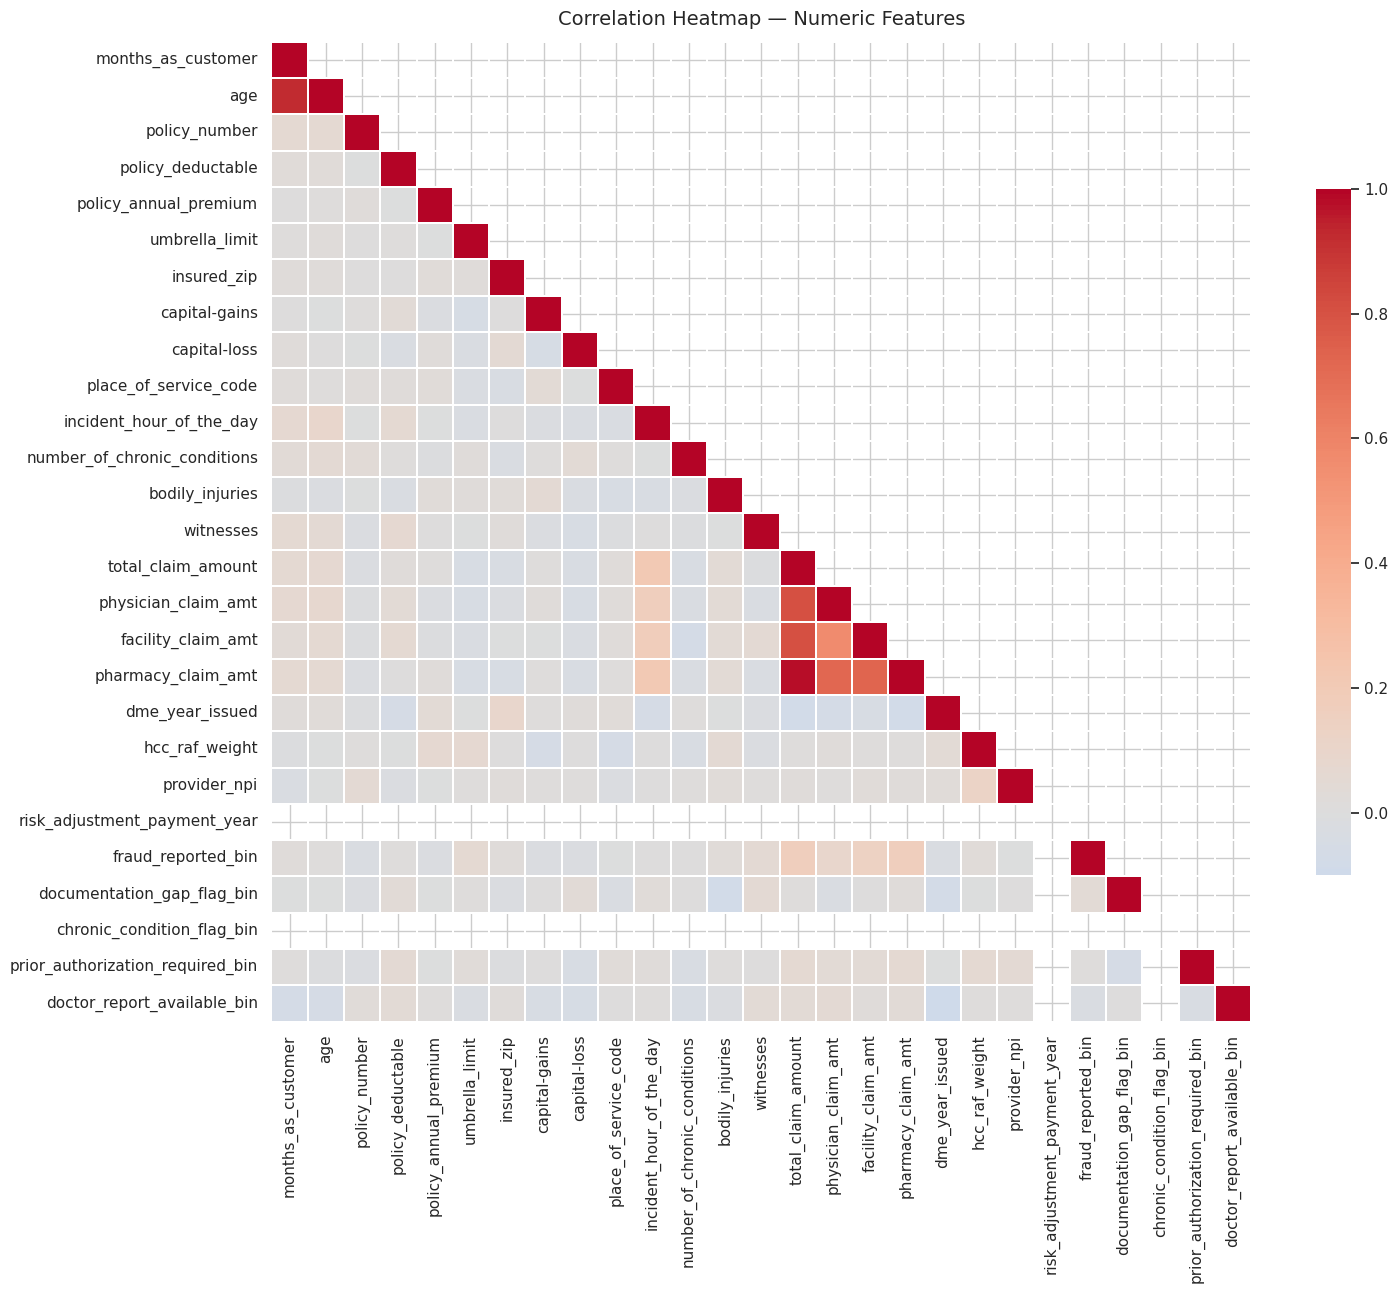

In [11]:
plt.figure(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_pearson, dtype=bool), k=1)
sns.heatmap(corr_pearson, mask=mask, annot=False, cmap="coolwarm", center=0,
            square=True, linewidths=0.3, cbar_kws={"shrink": 0.7})
plt.title("Correlation Heatmap — Numeric Features", fontsize=14, pad=12)
plt.tight_layout()
plt.show()

### 4.2 Correlation with Fraud Reported (Bar Chart)

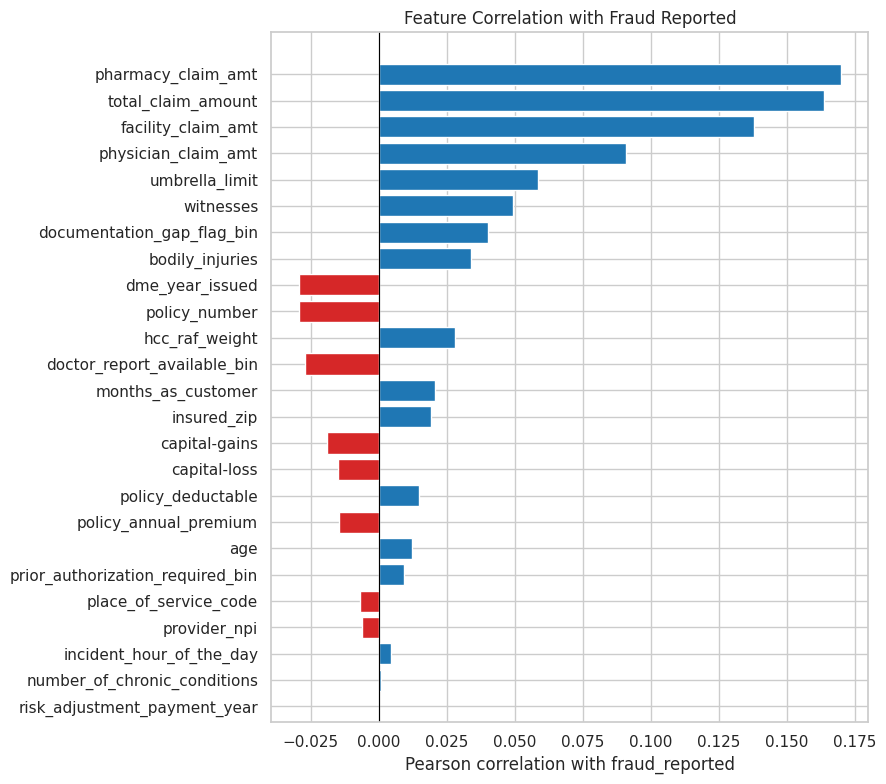

In [12]:
plt.figure(figsize=(9, 8))
colors = ["#d62728" if v < 0 else "#1f77b4" for v in fraud_corr.values]
plt.barh(fraud_corr.index, fraud_corr.values, color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Pearson correlation with fraud_reported")
plt.title("Feature Correlation with Fraud Reported")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 4.3 Pairplot of Key Claim Amount Variables

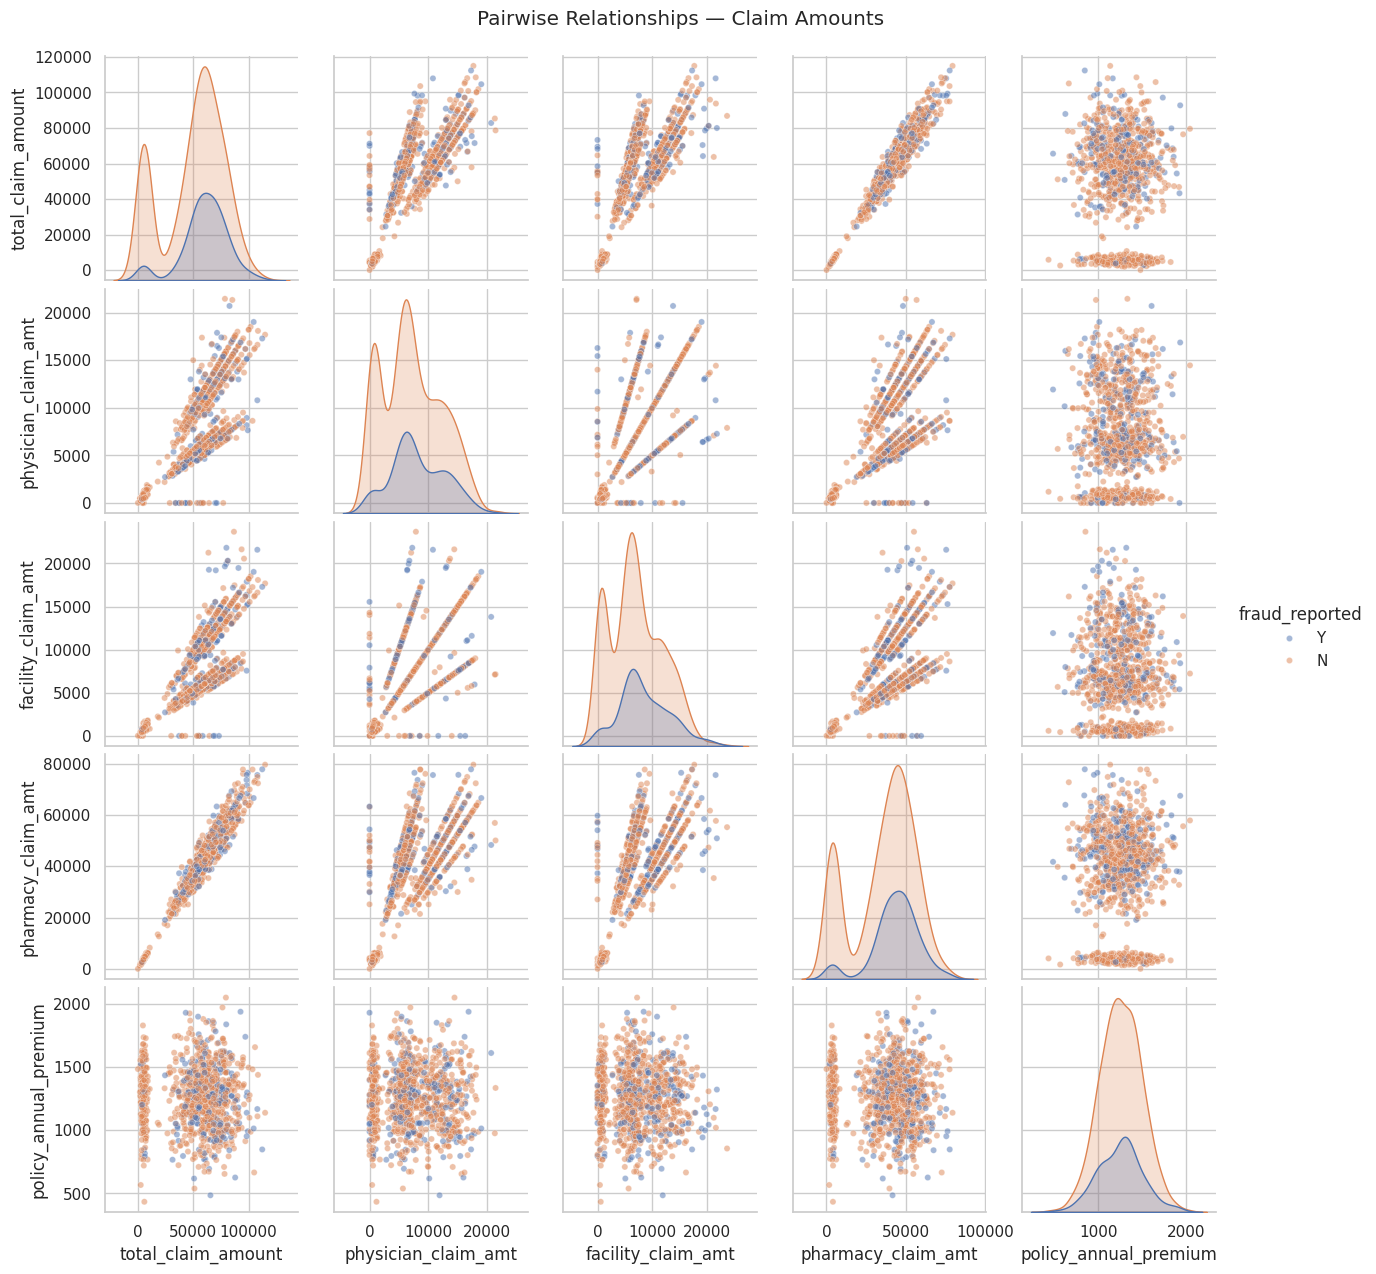

In [13]:
claim_cols = ["total_claim_amount", "physician_claim_amt", "facility_claim_amt",
              "pharmacy_claim_amt", "policy_annual_premium", "fraud_reported"]
sns.pairplot(df_clean[claim_cols], hue="fraud_reported", diag_kind="kde",
             plot_kws={"alpha": 0.5, "s": 20})
plt.suptitle("Pairwise Relationships — Claim Amounts", y=1.02)
plt.show()

### 4.4 Distribution of Total Claim Amount

/tmp/ipykernel_547/4150620040.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x="fraud_reported", y="total_claim_amount", ax=axes[1], palette="Set2")


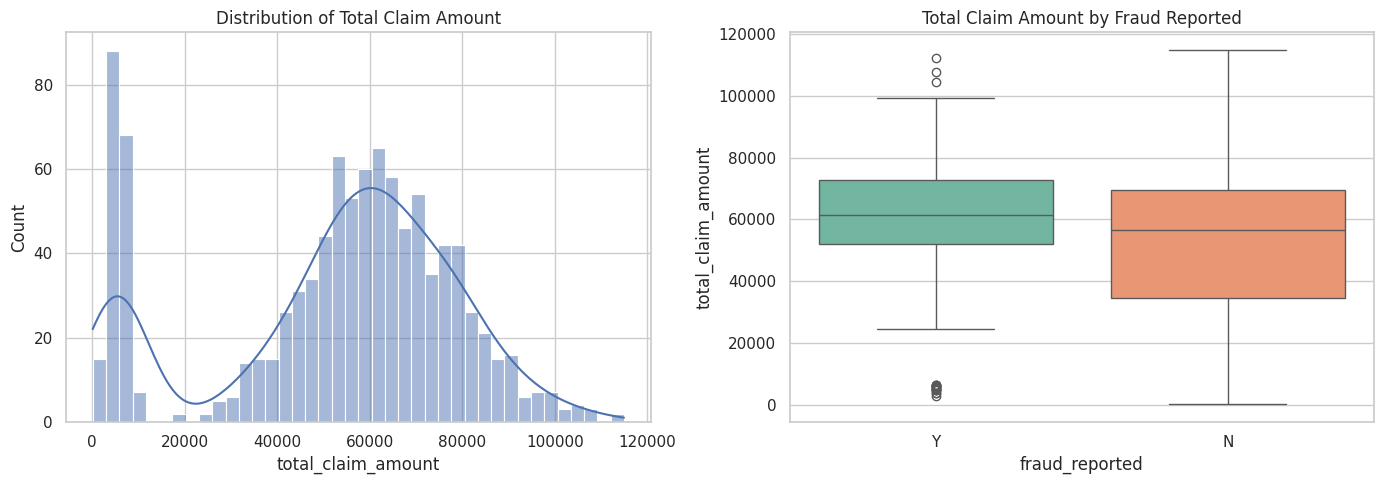

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df_clean["total_claim_amount"], bins=40, kde=True, ax=axes[0], color="#4c72b0")
axes[0].set_title("Distribution of Total Claim Amount")

sns.boxplot(data=df_clean, x="fraud_reported", y="total_claim_amount", ax=axes[1], palette="Set2")
axes[1].set_title("Total Claim Amount by Fraud Reported")
plt.tight_layout()
plt.show()

### 4.5 Age vs. Total Claim Amount, colored by Fraud

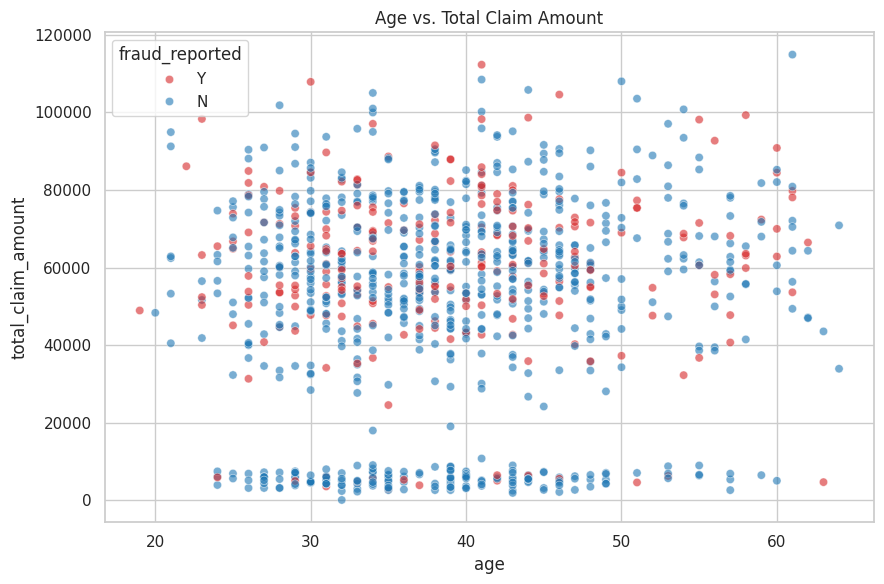

In [15]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df_clean, x="age", y="total_claim_amount", hue="fraud_reported",
                 alpha=0.6, palette={"Y": "#d62728", "N": "#1f77b4"})
plt.title("Age vs. Total Claim Amount")
plt.tight_layout()
plt.show()

### 4.6 Claim Amount Composition by Encounter Type

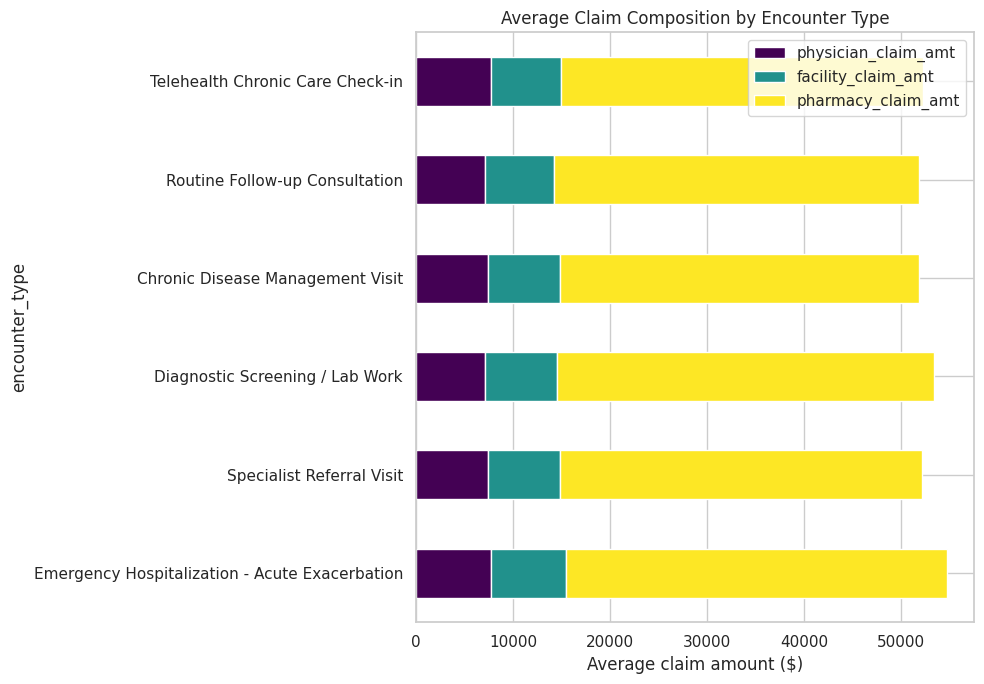

In [16]:
comp = (df_clean.groupby("encounter_type")[["physician_claim_amt", "facility_claim_amt", "pharmacy_claim_amt"]]
        .mean().sort_values("facility_claim_amt", ascending=False))
comp.plot(kind="barh", stacked=True, figsize=(10, 7), colormap="viridis")
plt.xlabel("Average claim amount ($)")
plt.title("Average Claim Composition by Encounter Type")
plt.tight_layout()
plt.show()

## 5. Summary

- The correlation matrix and heatmap above show which numeric fields move together (e.g. the claim-amount sub-components vs. `total_claim_amount` by construction).
- The bar chart isolates which features are most (linearly) associated with `fraud_reported`, useful as a quick feature-relevance screen before building a fraud model.
- The pairplot, boxplot, and scatter plot give a visual sense of distribution shape and separation between fraud/non-fraud claims.

Note: Pearson correlation only captures **linear** relationships. The Spearman table above should be checked alongside Pearson for monotonic-but-nonlinear relationships, and categorical fields (e.g. `insured_occupation`, `incident_state`) are not included in the numeric correlation matrix — consider encoding them (one-hot / target encoding) or using association measures like Cramér's V if you want to test those too.